# Notebook 5 — Statistical Confidence, Scaling, Error Diagnostics, and Business Metrics

## HMDA 2023 Loan Denial Prediction | Production Readiness Deep Dive

This notebook extends `4a_model_training.ipynb` and `4b_ensembles_evaluation.ipynb` with four production-grade analyses:

1. **Bootstrap confidence intervals** for model uncertainty
2. **Strong/weak scaling experiments** for serving performance
3. **Residual and error diagnostics** for explainability and risk discovery
4. **Business-oriented evaluation metrics** for decision impact

### Why this notebook matters

A leaderboard alone is not enough for deployment. Production model selection should include:

- **Statistical confidence**: Is the observed lift real or noise?
- **Operational scalability**: Can the model serve under load?
- **Failure mode visibility**: Where and why does the model fail?
- **Business impact**: How many costly misses/false alarms does it create?

### Artifacts expected

- `data/processed/model_results.json`
- `data/processed/ensemble_predictions_4a.json`
- `data/processed/model_results_4a.json`
- `data/processed/models/best_{lr,dt,rf,gbt}` (for scaling benchmarks)


In [1]:
# ============================================================
# Cell 1: Imports & Global Configuration
# ============================================================

import json
import math
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_fscore_support,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

DATA_DIR = Path("/Users/adi/Desktop/assignmt/project/data/processed")
MODEL_DIR = DATA_DIR / "models"

# Bootstrap controls
BOOTSTRAP_ITERATIONS = 400   # Use 1000+ for publication-grade intervals
RNG_SEED = 42

# Threshold for class prediction in diagnostics (unless noted)
DEFAULT_THRESHOLD = 0.50

print("Data dir:", DATA_DIR)
print("Bootstrap iterations:", BOOTSTRAP_ITERATIONS)


Data dir: /Users/adi/Desktop/assignmt/project/data/processed
Bootstrap iterations: 400


## Section 1 — Load Artifacts and Reconstruct Probability Matrix

### Why reconstruction is needed

`model_results.json` stores final aggregated metrics for all models, but sample-level uncertainty analysis needs per-row probabilities.

`ensemble_predictions_4a.json` contains sampled probabilities (`~76k rows`) for the 7 individual models:

- Naive Bayes, LR, SVM, DT, RF, GBT, MLP

This section reconstructs the remaining models on the same sample:

- Baseline
- SoftVote (all)
- WeightedVote (Top-3)
- Stacking-LR (using saved meta-learner coefficients from Notebook 4b output)


In [2]:
# ============================================================
# Cell 2: Load JSON Artifacts
# ============================================================

with open(DATA_DIR / "model_results.json") as f:
    MODEL_RESULTS = json.load(f)

with open(DATA_DIR / "model_results_4a.json") as f:
    MODEL_RESULTS_4A = json.load(f)

with open(DATA_DIR / "ensemble_predictions_4a.json") as f:
    PRED_RAW = json.load(f)

print("Models in final results:", list(MODEL_RESULTS.keys()))
print("Sample prediction models:", list(PRED_RAW.keys()))


Models in final results: ['M0_Baseline', 'M1_NaiveBayes', 'M2_LogisticRegression', 'M3_LinearSVM', 'M4_DecisionTree', 'M5_RandomForest', 'M6_GBT', 'M7_MLP', 'E_A_SoftVote_All', 'E_B_WeightedVote_Top3', 'E_C_Stacking_LR']
Sample prediction models: ['NaiveBayes', 'LR', 'SVM', 'DT', 'RF', 'GBT', 'MLP']


In [3]:
# ============================================================
# Cell 3: Build Unified Sample Probability Table (All Models)
# ============================================================

# Convert column-oriented JSON -> DataFrame per model
pred_frames = {name: pd.DataFrame(cols) for name, cols in PRED_RAW.items()}

# Base frame from NB (all were sampled with seed=42, same nominal size)
base = pred_frames["NaiveBayes"][["label"]].copy().reset_index(drop=True)
base["p_NaiveBayes"] = pred_frames["NaiveBayes"]["prob"].reset_index(drop=True)

for name in ["LR", "SVM", "DT", "RF", "GBT", "MLP"]:
    col = f"p_{name}"
    frame = pred_frames[name].reset_index(drop=True)
    min_len = min(len(base), len(frame))
    base = base.iloc[:min_len].copy()
    base[col] = frame["prob"].values[:min_len]

base["label"] = base["label"].astype(int)

# Derived model probabilities
base["M0_Baseline"] = 0.0
base["M1_NaiveBayes"] = base["p_NaiveBayes"]
base["M2_LogisticRegression"] = base["p_LR"]
base["M3_LinearSVM"] = base["p_SVM"]
base["M4_DecisionTree"] = base["p_DT"]
base["M5_RandomForest"] = base["p_RF"]
base["M6_GBT"] = base["p_GBT"]
base["M7_MLP"] = base["p_MLP"]

# Ensemble A: Soft vote of all available individual models
individual_cols = [
    "M1_NaiveBayes", "M2_LogisticRegression", "M3_LinearSVM",
    "M4_DecisionTree", "M5_RandomForest", "M6_GBT", "M7_MLP"
]
base["E_A_SoftVote_All"] = base[individual_cols].mean(axis=1)

# Ensemble B: Weighted vote by PR-AUC top-3 from NB4a style selection
weighted_members = ["M6_GBT", "M3_LinearSVM", "M1_NaiveBayes"]
raw_w = np.array([MODEL_RESULTS[m]["PR-AUC"] for m in weighted_members], dtype=float)
w = raw_w / raw_w.sum()
base["E_B_WeightedVote_Top3"] = (
    w[0] * base["M6_GBT"] +
    w[1] * base["M3_LinearSVM"] +
    w[2] * base["M1_NaiveBayes"]
)

# Ensemble C: Stacking LR reconstruction from Notebook 4b printed coefficients
# (Meta-learner on LR/DT/RF/GBT probabilities)
meta_coef = {
    "M2_LogisticRegression": 2.2068,
    "M4_DecisionTree": 2.3099,
    "M5_RandomForest": 2.5917,
    "M6_GBT": 2.3189,
}
meta_intercept = -5.3089

z = (
    meta_intercept
    + meta_coef["M2_LogisticRegression"] * base["M2_LogisticRegression"]
    + meta_coef["M4_DecisionTree"] * base["M4_DecisionTree"]
    + meta_coef["M5_RandomForest"] * base["M5_RandomForest"]
    + meta_coef["M6_GBT"] * base["M6_GBT"]
)
base["E_C_Stacking_LR"] = 1.0 / (1.0 + np.exp(-z))

ALL_MODEL_KEYS = list(MODEL_RESULTS.keys())
missing = [m for m in ALL_MODEL_KEYS if m not in base.columns]

print("Sample rows:", len(base))
print("Reconstructed columns:", [c for c in ALL_MODEL_KEYS if c in base.columns])
print("Missing columns:", missing)

base.head(3)


Sample rows: 76384
Reconstructed columns: ['M0_Baseline', 'M1_NaiveBayes', 'M2_LogisticRegression', 'M3_LinearSVM', 'M4_DecisionTree', 'M5_RandomForest', 'M6_GBT', 'M7_MLP', 'E_A_SoftVote_All', 'E_B_WeightedVote_Top3', 'E_C_Stacking_LR']
Missing columns: []


,label,p_NaiveBayes,p_LR,p_SVM,p_DT,p_RF,p_GBT,p_MLP,M0_Baseline,M1_NaiveBayes,M2_LogisticRegression,M3_LinearSVM,M4_DecisionTree,M5_RandomForest,M6_GBT,M7_MLP,E_A_SoftVote_All,E_B_WeightedVote_Top3,E_C_Stacking_LR
0,1,1.0,0.992491,0.245815,0.999833,0.839500,0.989982,0.993775,0.0,1.0,0.992491,0.245815,0.999833,0.839500,0.989982,0.993775,0.865914,0.745047,0.974968
1,1,1.0,0.990651,0.234455,0.999833,0.917864,0.989852,0.993776,0.0,1.0,0.990651,0.234455,0.999833,0.917864,0.989852,0.993776,0.875204,0.741214,0.979386
2,0,0.0,0.002993,0.784976,0.000000,0.055760,0.009805,0.005616,0.0,0.0,0.002993,0.784976,0.000000,0.055760,0.009805,0.005616,0.122736,0.265154,0.005852


In [4]:
# ============================================================
# Cell 4: Metric Helpers
# ============================================================

def confusion_counts(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[int, int, int, int]:
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fp, fn, tn


def compute_metrics(y_true: np.ndarray, prob: np.ndarray, threshold: float = DEFAULT_THRESHOLD) -> Dict[str, float]:
    y_pred = (prob >= threshold).astype(int)
    tp, fp, fn, tn = confusion_counts(y_true, y_pred)

    try:
        roc_auc = roc_auc_score(y_true, prob)
    except Exception:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, prob)
    except Exception:
        pr_auc = np.nan

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", pos_label=1, zero_division=0
    )

    return {
        "ROC-AUC": float(roc_auc),
        "PR-AUC": float(pr_auc),
        "Denial_Precision": float(prec),
        "Denial_Recall": float(rec),
        "Denial_F1": float(f1),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Brier": float(brier_score_loss(y_true, prob)),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }


def ece_score(y_true: np.ndarray, prob: np.ndarray, n_bins: int = 15) -> float:
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.digitize(prob, bins) - 1
    idx = np.clip(idx, 0, n_bins - 1)
    ece = 0.0
    n = len(y_true)

    for b in range(n_bins):
        mask = idx == b
        if not np.any(mask):
            continue
        conf = prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / n) * abs(acc - conf)

    return float(ece)


In [5]:
# ============================================================
# Cell 5: Point Metrics from Sample (Sanity + Recomputed Diagnostics)
# ============================================================

y = base["label"].values.astype(int)
point_rows = []

for m in ALL_MODEL_KEYS:
    if m not in base.columns:
        continue
    metrics = compute_metrics(y, base[m].values.astype(float), threshold=DEFAULT_THRESHOLD)
    metrics["Model"] = m
    point_rows.append(metrics)

point_df = pd.DataFrame(point_rows)
point_df = point_df[[
    "Model", "ROC-AUC", "PR-AUC", "Denial_F1", "Denial_Precision", "Denial_Recall", "Accuracy", "Brier", "TP", "FP", "FN", "TN"
]].sort_values("PR-AUC", ascending=False).reset_index(drop=True)

# Compare sample PR-AUC against full-test artifact PR-AUC
artifact_pr = {k: v["PR-AUC"] for k, v in MODEL_RESULTS.items()}
point_df["PR-AUC_full_artifact"] = point_df["Model"].map(artifact_pr)
point_df["PR-AUC_delta_sample_minus_full"] = point_df["PR-AUC"] - point_df["PR-AUC_full_artifact"]

print("Sample-based leaderboard (diagnostic sample, not full test):")
point_df.head(12)


Sample-based leaderboard (diagnostic sample, not full test):


,Model,ROC-AUC,PR-AUC,Denial_F1,Denial_Precision,Denial_Recall,Accuracy,Brier,TP,FP,FN,TN,PR-AUC_full_artifact,PR-AUC_delta_sample_minus_full
0,M6_GBT,0.999754,0.999181,0.988945,0.987392,0.990502,0.994292,0.004841,19501,249,187,56447,0.998941,0.000240
1,M4_DecisionTree,0.999689,0.998752,0.988518,0.986592,0.990451,0.994069,0.004697,19500,265,188,56431,0.998181,0.000572
2,M2_LogisticRegression,0.999621,0.998696,0.987842,0.987266,0.988419,0.993729,0.005541,19460,251,228,56445,0.998865,-0.000169
3,E_C_Stacking_LR,0.999615,0.998541,0.990249,0.992701,0.987810,0.994986,0.004270,19448,143,240,56553,0.998774,-0.000234
4,E_A_SoftVote_All,0.999560,0.998343,0.989449,0.992941,0.985981,0.994580,0.020632,19412,138,276,56558,0.998800,-0.000457
5,M5_RandomForest,0.999407,0.997771,0.988637,0.989568,0.987708,0.994148,0.013655,19446,205,242,56491,0.998133,-0.000362
6,M1_NaiveBayes,0.998329,0.993097,0.984600,0.991857,0.977448,0.992119,0.007761,19244,158,444,56538,0.993650,-0.000553
7,E_B_WeightedVote_Top3,0.998986,0.992403,0.985044,0.991661,0.978515,0.992341,0.075142,19265,162,423,56534,0.998964,-0.006561
8,M7_MLP,0.989239,0.983585,0.987317,0.992102,0.982578,0.993493,0.006412,19345,154,343,56542,0.984634,-0.001049
9,M0_Baseline,0.500000,0.257750,0.000000,0.000000,0.000000,0.742250,0.257750,0,0,19688,56696,0.258869,-0.001118


## Section 2 — Bootstrap Confidence Intervals (Uncertainty Quantification)

### Concept deep dive

A single test score (for example `PR-AUC=0.9989`) is a point estimate. It does not tell us uncertainty.

**Bootstrap** approximates the sampling distribution by resampling rows with replacement:

1. Draw `N` rows from the test sample with replacement
2. Recompute metric
3. Repeat `B` times
4. Use percentile intervals (`2.5%`, `97.5%`) as a 95% CI

### Why this is important in production decisions

Two models with very close PR-AUC values may be statistically indistinguishable. If confidence intervals overlap heavily, prefer the simpler/faster model unless business constraints require the tiny lift.


In [6]:
# ============================================================
# Cell 6: Bootstrap Engine
# ============================================================

def bootstrap_metrics(
    labels: np.ndarray,
    pred_table: pd.DataFrame,
    model_keys: List[str],
    n_iter: int = BOOTSTRAP_ITERATIONS,
    threshold: float = DEFAULT_THRESHOLD,
    seed: int = RNG_SEED,
) -> Dict[str, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    n = len(labels)

    records = {m: [] for m in model_keys}

    for b in range(n_iter):
        idx = rng.integers(0, n, n)
        yb = labels[idx]

        for m in model_keys:
            pb = pred_table[m].values[idx]
            met = compute_metrics(yb, pb, threshold=threshold)
            met["iter"] = b
            records[m].append(met)

        if (b + 1) % 100 == 0:
            print(f"  bootstrap {b+1}/{n_iter}")

    return {m: pd.DataFrame(rows) for m, rows in records.items()}


boot_raw = bootstrap_metrics(y, base, [m for m in ALL_MODEL_KEYS if m in base.columns])
print("Bootstrap completed for", len(boot_raw), "models")


  bootstrap 100/400
  bootstrap 200/400
  bootstrap 300/400
  bootstrap 400/400
Bootstrap completed for 11 models


In [7]:
# ============================================================
# Cell 7: Summarize Bootstrap CIs
# ============================================================

def summarize_ci(df: pd.DataFrame, metric: str, alpha: float = 0.05):
    vals = df[metric].dropna().values
    return {
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=1)),
        "lo": float(np.quantile(vals, alpha / 2)),
        "hi": float(np.quantile(vals, 1 - alpha / 2)),
    }

summary_rows = []
for model, dfm in boot_raw.items():
    row = {"Model": model}
    for metric in ["PR-AUC", "ROC-AUC", "Denial_F1", "Denial_Recall", "Denial_Precision", "Accuracy", "Brier"]:
        s = summarize_ci(dfm, metric)
        row[f"{metric}_mean"] = s["mean"]
        row[f"{metric}_lo"] = s["lo"]
        row[f"{metric}_hi"] = s["hi"]
    summary_rows.append(row)

boot_summary = pd.DataFrame(summary_rows).sort_values("PR-AUC_mean", ascending=False).reset_index(drop=True)
boot_summary.head(12)


,Model,PR-AUC_mean,PR-AUC_lo,PR-AUC_hi,ROC-AUC_mean,ROC-AUC_lo,ROC-AUC_hi,Denial_F1_mean,Denial_F1_lo,Denial_F1_hi,Denial_Recall_mean,Denial_Recall_lo,Denial_Recall_hi,Denial_Precision_mean,Denial_Precision_lo,Denial_Precision_hi,Accuracy_mean,Accuracy_lo,Accuracy_hi,Brier_mean,Brier_lo,Brier_hi
0,M6_GBT,0.999174,0.998836,0.999428,0.999754,0.999693,0.999808,0.988944,0.987884,0.989947,0.990525,0.989195,0.991673,0.987369,0.985683,0.988992,0.994291,0.993741,0.994803,0.004842,0.004511,0.005169
1,M4_DecisionTree,0.998750,0.998343,0.999130,0.999689,0.999614,0.999759,0.988539,0.987535,0.989629,0.990502,0.989251,0.991728,0.986584,0.984903,0.988395,0.994079,0.993545,0.994633,0.004690,0.004353,0.005016
2,M2_LogisticRegression,0.998695,0.998269,0.999017,0.999621,0.999535,0.999694,0.987881,0.986817,0.988875,0.988477,0.986987,0.989836,0.987287,0.985600,0.988878,0.993748,0.993192,0.994279,0.005533,0.005180,0.005906
3,E_C_Stacking_LR,0.998535,0.998014,0.998927,0.999614,0.999507,0.999706,0.990278,0.989240,0.991168,0.987845,0.986297,0.989409,0.992722,0.991476,0.993992,0.995000,0.994501,0.995471,0.004257,0.003907,0.004641
4,E_A_SoftVote_All,0.998338,0.997849,0.998816,0.999559,0.999450,0.999663,0.989487,0.988512,0.990482,0.986025,0.984501,0.987430,0.992973,0.991632,0.994151,0.994598,0.994083,0.995117,0.020625,0.020375,0.020908
5,M5_RandomForest,0.997765,0.997108,0.998334,0.999406,0.999271,0.999528,0.988678,0.987616,0.989683,0.987751,0.986164,0.989308,0.989608,0.988078,0.991026,0.994168,0.993637,0.994698,0.013650,0.013353,0.013969
6,M1_NaiveBayes,0.993124,0.991988,0.994203,0.998338,0.998065,0.998590,0.984637,0.983370,0.985795,0.977501,0.975465,0.979360,0.991879,0.990522,0.993155,0.992136,0.991490,0.992708,0.007740,0.007187,0.008391
7,E_B_WeightedVote_Top3,0.992458,0.989990,0.994825,0.998987,0.998781,0.999189,0.985091,0.983897,0.986172,0.978588,0.976519,0.980411,0.991681,0.990379,0.992935,0.992364,0.991739,0.992918,0.075137,0.074923,0.075370
8,M7_MLP,0.983772,0.981658,0.986003,0.989277,0.988074,0.990373,0.987382,0.986305,0.988395,0.982663,0.980969,0.984285,0.992147,0.990756,0.993340,0.993525,0.992969,0.994057,0.006384,0.005854,0.006929
9,M0_Baseline,0.257804,0.254595,0.260621,0.500000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.742196,0.739379,0.745405,0.257804,0.254595,0.260621


In [8]:
# ============================================================
# Cell 8: Probability of Being Best (PR-AUC)
# ============================================================

# Build iteration-wise PR-AUC matrix
iters = sorted(next(iter(boot_raw.values()))["iter"].unique())
pr_mat = pd.DataFrame(index=iters)

for model, dfm in boot_raw.items():
    pr_mat[model] = dfm.sort_values("iter")["PR-AUC"].values

best_counts = pr_mat.idxmax(axis=1).value_counts(normalize=True)
prob_best = (
    best_counts.rename("Prob_Best_PR_AUC")
    .reset_index()
    .rename(columns={"index": "Model"})
    .sort_values("Prob_Best_PR_AUC", ascending=False)
)

prob_best


,Model,Prob_Best_PR_AUC
0,M6_GBT,0.995
1,M2_LogisticRegression,0.005


In [9]:
# ============================================================
# Cell 9: Champion-vs-Rest Uncertainty (Delta PR-AUC)
# ============================================================

champion = boot_summary.iloc[0]["Model"]
print("Champion by bootstrap mean PR-AUC:", champion)

delta_rows = []
for m in pr_mat.columns:
    if m == champion:
        continue
    delta = pr_mat[champion] - pr_mat[m]
    lo, hi = np.quantile(delta, [0.025, 0.975])
    delta_rows.append({
        "Model": m,
        "Delta_PR_AUC_mean": float(delta.mean()),
        "Delta_PR_AUC_lo": float(lo),
        "Delta_PR_AUC_hi": float(hi),
        "Significant_95pct": not (lo <= 0 <= hi),
    })

delta_df = pd.DataFrame(delta_rows).sort_values("Delta_PR_AUC_mean", ascending=False)
delta_df


Champion by bootstrap mean PR-AUC: M6_GBT


,Model,Delta_PR_AUC_mean,Delta_PR_AUC_lo,Delta_PR_AUC_hi,Significant_95pct
3,M3_LinearSVM,0.857447,0.855655,0.859378,True
0,M0_Baseline,0.741370,0.738532,0.744541,True
6,M7_MLP,0.015402,0.013246,0.017471,True
8,E_B_WeightedVote_Top3,0.006716,0.004463,0.009167,True
1,M1_NaiveBayes,0.006050,0.005075,0.007176,True
5,M5_RandomForest,0.001409,0.000836,0.002032,True
7,E_A_SoftVote_All,0.000837,0.000386,0.001321,True
9,E_C_Stacking_LR,0.000640,0.000163,0.001149,True
2,M2_LogisticRegression,0.000480,0.000129,0.000849,True
4,M4_DecisionTree,0.000424,0.000175,0.000698,True


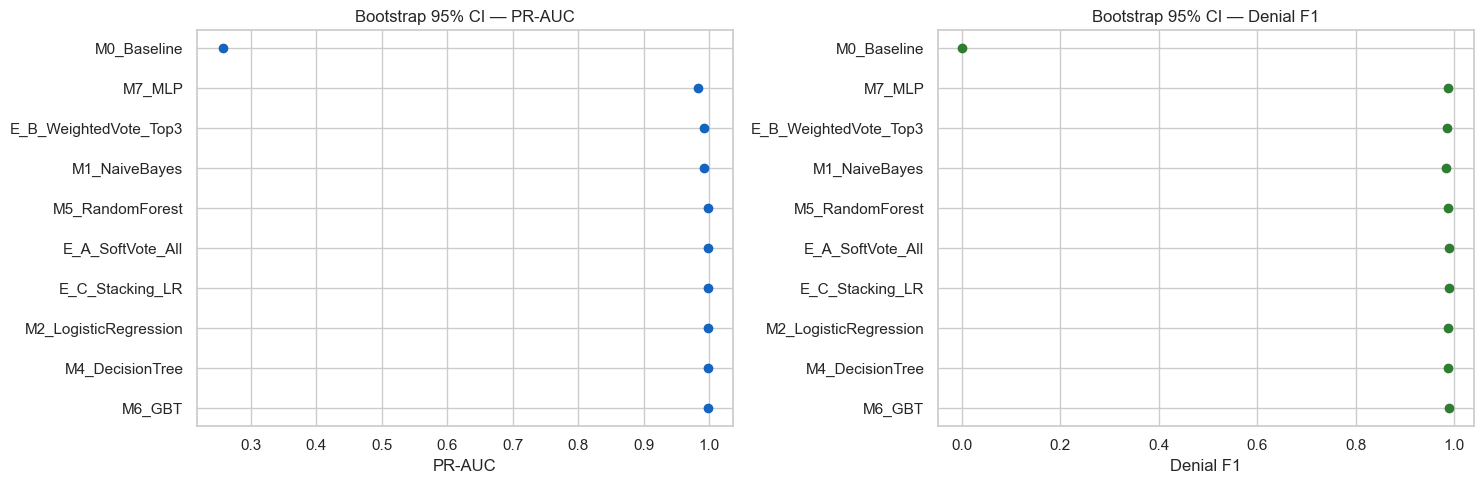

In [10]:
# ============================================================
# Cell 10: CI Plot (PR-AUC & Denial F1)
# ============================================================

plot_df = boot_summary.copy().head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PR-AUC CI
axes[0].errorbar(
    plot_df["PR-AUC_mean"],
    plot_df["Model"],
    xerr=[plot_df["PR-AUC_mean"] - plot_df["PR-AUC_lo"], plot_df["PR-AUC_hi"] - plot_df["PR-AUC_mean"]],
    fmt="o",
    color="#1565C0",
    ecolor="#90CAF9",
    capsize=3,
)
axes[0].set_title("Bootstrap 95% CI — PR-AUC")
axes[0].set_xlabel("PR-AUC")

# Denial F1 CI
axes[1].errorbar(
    plot_df["Denial_F1_mean"],
    plot_df["Model"],
    xerr=[plot_df["Denial_F1_mean"] - plot_df["Denial_F1_lo"], plot_df["Denial_F1_hi"] - plot_df["Denial_F1_mean"]],
    fmt="o",
    color="#2E7D32",
    ecolor="#A5D6A7",
    capsize=3,
)
axes[1].set_title("Bootstrap 95% CI — Denial F1")
axes[1].set_xlabel("Denial F1")

plt.tight_layout()
plt.show()


## Section 3 — Residual and Error Analysis

### Concept deep dive

For probabilistic classification, a useful residual is:

`residual = y_true - p_hat`

Interpretation:

- Large positive residual: model was under-confident on a true denial
- Large negative residual: model was over-confident on a false denial
- Residual spread and tails reveal calibration and hard-case behavior

This section analyzes:

- Residual distribution per model
- Calibration quality (Brier + ECE)
- Error overlap between models (diversity/complementarity)
- Hard-case cohorts where most models fail


In [11]:
# ============================================================
# Cell 11: Residual Statistics & Calibration Summary
# ============================================================

res_rows = []
for m in [k for k in ALL_MODEL_KEYS if k in base.columns]:
    p = base[m].values
    r = y - p
    yhat = (p >= DEFAULT_THRESHOLD).astype(int)
    err = (yhat != y).astype(int)
    res_rows.append({
        "Model": m,
        "Residual_Mean": float(np.mean(r)),
        "Residual_STD": float(np.std(r, ddof=1)),
        "Residual_AbsMean": float(np.mean(np.abs(r))),
        "Error_Rate": float(err.mean()),
        "Brier": float(brier_score_loss(y, p)),
        "ECE_15bins": ece_score(y, p, n_bins=15),
    })

residual_summary = pd.DataFrame(res_rows).sort_values("Brier").reset_index(drop=True)
residual_summary


,Model,Residual_Mean,Residual_STD,Residual_AbsMean,Error_Rate,Brier,ECE_15bins
0,E_C_Stacking_LR,-0.000122,0.065344,0.016508,0.005014,0.004270,0.009454
1,M4_DecisionTree,-0.004877,0.068365,0.010100,0.005931,0.004697,0.004877
2,M6_GBT,-0.009618,0.068913,0.019586,0.005708,0.004841,0.013448
3,M2_LogisticRegression,-0.007718,0.074035,0.015727,0.006271,0.005541,0.008629
4,M7_MLP,-0.000036,0.080078,0.012329,0.006507,0.006412,0.000805
5,M1_NaiveBayes,0.003731,0.088021,0.007883,0.007881,0.007761,0.007756
6,M5_RandomForest,-0.043657,0.108395,0.090039,0.005852,0.013655,0.082949
7,E_A_SoftVote_All,-0.064839,0.128173,0.134635,0.005420,0.020632,0.127529
8,E_B_WeightedVote_Top3,-0.132649,0.239890,0.271643,0.007659,0.075142,0.263118
9,M0_Baseline,0.257750,0.437399,0.257750,0.257750,0.257750,0.257750


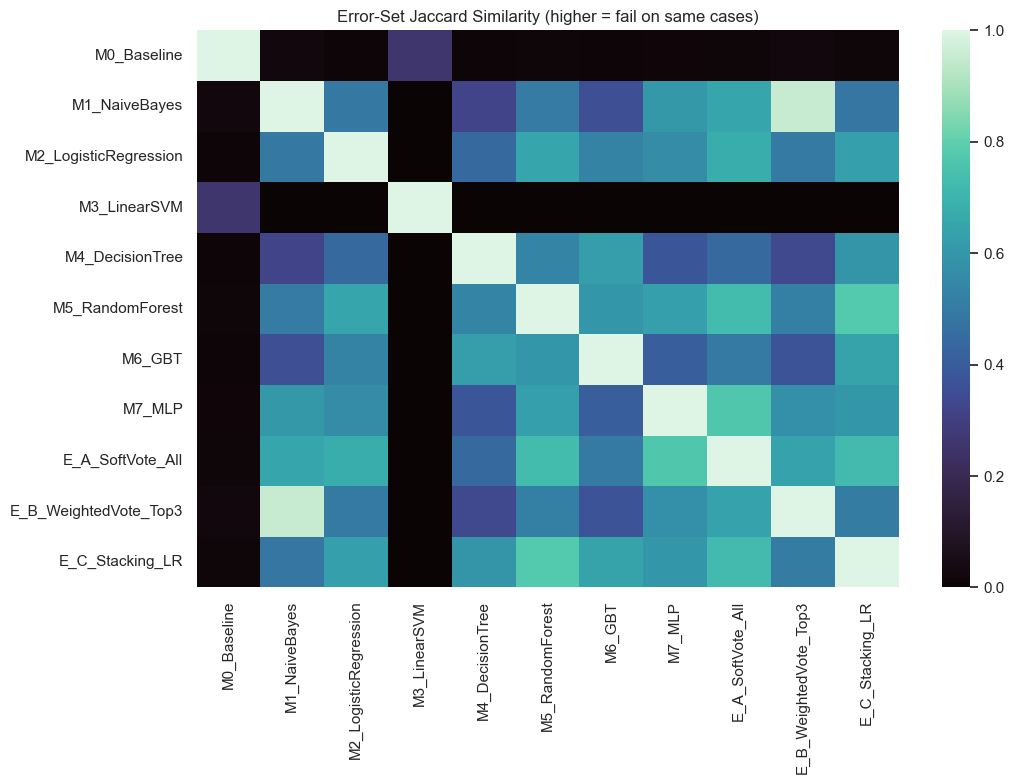

,M0_Baseline,M1_NaiveBayes,M2_LogisticRegression,M3_LinearSVM,M4_DecisionTree,M5_RandomForest,M6_GBT,M7_MLP,E_A_SoftVote_All,E_B_WeightedVote_Top3,E_C_Stacking_LR
M0_Baseline,1.000,0.022,0.011,0.254,0.009,0.012,0.009,0.017,0.014,0.021,0.012
M1_NaiveBayes,0.022,1.000,0.491,0.003,0.319,0.503,0.352,0.602,0.652,0.952,0.486
M2_LogisticRegression,0.011,0.491,1.000,0.001,0.443,0.654,0.525,0.559,0.675,0.499,0.633
M3_LinearSVM,0.254,0.003,0.001,1.000,0.002,0.001,0.002,0.001,0.000,0.003,0.001
M4_DecisionTree,0.009,0.319,0.443,0.002,1.000,0.533,0.622,0.377,0.445,0.334,0.592


In [12]:
# ============================================================
# Cell 12: Error Overlap Matrix (Jaccard of Error Sets)
# ============================================================

model_keys = [k for k in ALL_MODEL_KEYS if k in base.columns]
error_vectors = {}

for m in model_keys:
    yhat = (base[m].values >= DEFAULT_THRESHOLD).astype(int)
    error_vectors[m] = (yhat != y)

jaccard = pd.DataFrame(index=model_keys, columns=model_keys, dtype=float)
for m1 in model_keys:
    for m2 in model_keys:
        e1 = error_vectors[m1]
        e2 = error_vectors[m2]
        inter = np.logical_and(e1, e2).sum()
        union = np.logical_or(e1, e2).sum()
        jaccard.loc[m1, m2] = float(inter / union) if union > 0 else 0.0

plt.figure(figsize=(11, 8))
sns.heatmap(jaccard.astype(float), cmap="mako", vmin=0, vmax=1)
plt.title("Error-Set Jaccard Similarity (higher = fail on same cases)")
plt.tight_layout()
plt.show()

jaccard.round(3).head()


In [13]:
# ============================================================
# Cell 13: Hard-Case Mining
# ============================================================

err_mat = pd.DataFrame({m: error_vectors[m].astype(int) for m in model_keys})
err_mat["n_models_wrong"] = err_mat.sum(axis=1)
err_mat["label"] = y

n_models = len(model_keys)
hard_threshold = max(3, int(math.ceil(0.70 * n_models)))

hard_cases = err_mat[err_mat["n_models_wrong"] >= hard_threshold].copy()
all_wrong = err_mat[err_mat["n_models_wrong"] == n_models].copy()

print(f"Models considered: {n_models}")
print(f"Hard-case threshold (>=70% wrong): {hard_threshold}")
print(f"Hard cases: {len(hard_cases):,} ({len(hard_cases)/len(err_mat)*100:.2f}%)")
print(f"All-models-wrong cases: {len(all_wrong):,} ({len(all_wrong)/len(err_mat)*100:.2f}%)")

if len(hard_cases) > 0:
    print("Hard-case label distribution:")
    print(hard_cases["label"].value_counts(normalize=True).rename("share").round(4))


Models considered: 11
Hard-case threshold (>=70% wrong): 8
Hard cases: 308 (0.40%)
All-models-wrong cases: 0 (0.00%)
Hard-case label distribution:
label
1    0.7143
0    0.2857
Name: share, dtype: float64


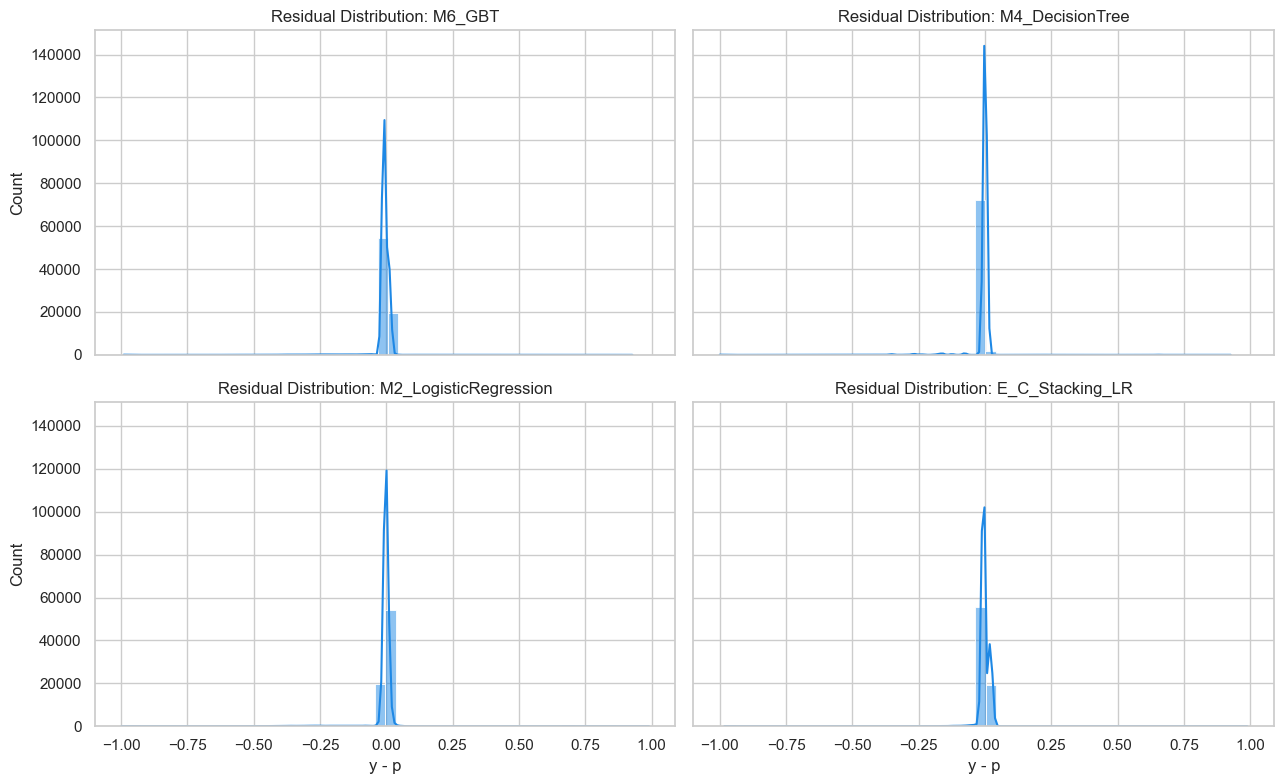

In [14]:
# ============================================================
# Cell 14: Residual Distribution Plot (Top Models)
# ============================================================

top_models = boot_summary.head(4)["Model"].tolist()

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)
axes = axes.ravel()

for ax, m in zip(axes, top_models):
    residuals = y - base[m].values
    sns.histplot(residuals, bins=50, kde=True, ax=ax, color="#1E88E5")
    ax.set_title(f"Residual Distribution: {m}")
    ax.set_xlabel("y - p")

plt.tight_layout()
plt.show()


## Section 4 — Business-Oriented Evaluation Metrics

### Concept deep dive

Business decisions require translating confusion outcomes to cost/risk.

Let:

- `FP` = false denial alert (operational overhead, unnecessary investigation)
- `FN` = missed denial risk (compliance/financial risk)

Expected loss:

`Loss = FP * Cost_FP + FN * Cost_FN`

This section provides:

- Cost per 1,000 applications
- Savings vs baseline model
- Operational volume metrics (alerts, misses)
- Threshold policy trade-offs for top candidates


In [15]:
# ============================================================
# Cell 15: Business Cost Table from Full-Test Confusion Matrices
# ============================================================

# Tunable policy costs (edit to match org economics)
COST_FP = 250.0     # cost of a false alert
COST_FN = 2500.0    # cost of a missed denial (typically much higher)

biz_rows = []
for model, m in MODEL_RESULTS.items():
    c = m.get("Confusion", {})
    tp, fp, fn, tn = c.get("TP", 0), c.get("FP", 0), c.get("FN", 0), c.get("TN", 0)
    total = tp + fp + fn + tn

    expected_loss = fp * COST_FP + fn * COST_FN
    cost_per_1k = (expected_loss / total) * 1000 if total > 0 else np.nan

    predicted_positive = tp + fp
    alert_rate = predicted_positive / total if total > 0 else np.nan
    miss_rate = fn / (tp + fn) if (tp + fn) > 0 else np.nan

    biz_rows.append({
        "Model": model,
        "PR-AUC": m.get("PR-AUC", np.nan),
        "Denial_F1": m.get("Denial_F1", np.nan),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Expected_Loss": expected_loss,
        "Cost_per_1k_apps": cost_per_1k,
        "Alert_Rate": alert_rate,
        "Miss_Rate": miss_rate,
    })

biz_df = pd.DataFrame(biz_rows).sort_values("Cost_per_1k_apps").reset_index(drop=True)

baseline_cost = biz_df.loc[biz_df["Model"] == "M0_Baseline", "Cost_per_1k_apps"].iloc[0]
biz_df["Savings_vs_Baseline_per_1k"] = baseline_cost - biz_df["Cost_per_1k_apps"]

biz_df.head(12)


,Model,PR-AUC,Denial_F1,TP,FP,FN,TN,Expected_Loss,Cost_per_1k_apps,Alert_Rate,Miss_Rate,Savings_vs_Baseline_per_1k
0,M6_GBT,0.998941,0.988615,393219,5213,3844,1131564,10913250.0,7114.985918,0.259761,0.009681,640056.492203
1,M4_DecisionTree,0.998181,0.988099,393170,5578,3893,1131199,11127000.0,7254.342043,0.259967,0.009804,639917.136077
2,E_A_SoftVote_All,0.998800,0.989088,392887,4493,4176,1132284,11563250.0,7538.758932,0.259075,0.010517,639632.719188
3,M2_LogisticRegression,0.998865,0.988011,392471,4933,4592,1131844,12713250.0,8288.511188,0.259091,0.011565,638882.966933
4,E_C_Stacking_LR,0.998774,0.990128,392203,2961,4860,1133816,12890250.0,8403.907839,0.257631,0.012240,638767.570281
5,M5_RandomForest,0.998133,0.988780,392200,4038,4863,1132739,13167000.0,8584.337349,0.258331,0.012247,638587.140771
6,M3_LinearSVM,0.997552,0.989038,391093,2699,5970,1134078,15599750.0,10170.389350,0.256736,0.015035,637001.088771
7,M7_MLP,0.984634,0.987502,390174,2987,6889,1133790,17969250.0,11715.204976,0.256325,0.017350,635456.273145
8,M1_NaiveBayes,0.993650,0.984607,388002,3071,9061,1133706,23420250.0,15269.030668,0.254963,0.022820,631902.447452
9,M0_Baseline,0.258869,0.000000,0,0,397063,1136777,992657500.0,647171.478120,0.000000,1.000000,0.000000


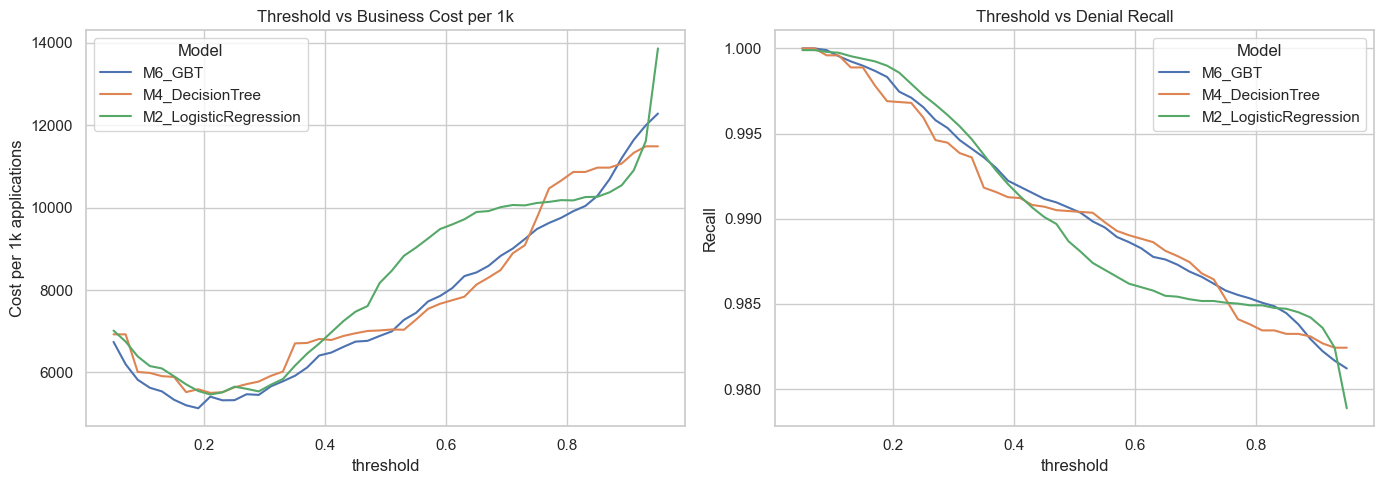

,Model,threshold,precision,recall,f1,cost_per_1k
100,M2_LogisticRegression,0.21,0.933967,0.998578,0.965192,5465.804357
101,M2_LogisticRegression,0.23,0.939014,0.997918,0.967570,5518.171345
104,M2_LogisticRegression,0.29,0.955050,0.996089,0.975138,5541.081902
54,M4_DecisionTree,0.21,0.948666,0.996851,0.972162,5505.079598
55,M4_DecisionTree,0.23,0.948893,0.996800,0.972257,5521.444282
52,M4_DecisionTree,0.17,0.939817,0.997816,0.967949,5524.717218
7,M6_GBT,0.19,0.940746,0.998324,0.968680,5131.964809
6,M6_GBT,0.17,0.936643,0.998679,0.966667,5203.969418
9,M6_GBT,0.23,0.948908,0.997105,0.972409,5325.068077


In [16]:
# ============================================================
# Cell 16: Threshold Policy Frontier (Top 3 by Bootstrap PR-AUC)
# ============================================================

thresholds = np.arange(0.05, 0.96, 0.02)
top3_models = boot_summary.head(3)["Model"].tolist()

frontier_rows = []
for m in top3_models:
    p = base[m].values
    for t in thresholds:
        yhat = (p >= t).astype(int)
        tp, fp, fn, tn = confusion_counts(y, yhat)
        prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", pos_label=1, zero_division=0)
        total = tp + fp + fn + tn
        expected_loss = fp * COST_FP + fn * COST_FN
        frontier_rows.append({
            "Model": m,
            "threshold": t,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "cost_per_1k": (expected_loss / total) * 1000,
        })

frontier = pd.DataFrame(frontier_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=frontier, x="threshold", y="cost_per_1k", hue="Model", ax=axes[0])
axes[0].set_title("Threshold vs Business Cost per 1k")
axes[0].set_ylabel("Cost per 1k applications")

sns.lineplot(data=frontier, x="threshold", y="recall", hue="Model", ax=axes[1])
axes[1].set_title("Threshold vs Denial Recall")
axes[1].set_ylabel("Recall")

plt.tight_layout()
plt.show()

frontier.sort_values(["Model", "cost_per_1k"]).groupby("Model").head(3)


## Section 5 — Strong and Weak Scaling Experiments

### Concept deep dive

- **Strong scaling**: fixed data size, increase compute parallelism. Desired behavior: runtime decreases.
- **Weak scaling**: increase data and parallelism proportionally. Desired behavior: runtime stays stable.

### Practical constraint

Only these models are serialized for direct Spark inference benchmarking:

- `best_lr`, `best_dt`, `best_rf`, `best_gbt`

For the remaining models, we still include an **analytical scaling appendix** based on recorded wall-clock metrics from `model_results.json`.


In [17]:
# ============================================================
# Cell 17: Analytical Scaling Appendix (All Models)
# ============================================================

rows = []
for model, m in MODEL_RESULTS.items():
    c = m.get("Confusion", {})
    n = c.get("TP", 0) + c.get("FP", 0) + c.get("FN", 0) + c.get("TN", 0)
    t = float(m.get("Train_Time_s", np.nan))
    rows.append({
        "Model": model,
        "Train_Time_s": t,
        "Test_Rows": n,
        "Rows_per_sec_equiv": (n / t) if t > 0 else np.nan,
        "PR-AUC": m.get("PR-AUC", np.nan),
    })

scaling_analytic = pd.DataFrame(rows).sort_values("Train_Time_s")
scaling_analytic


,Model,Train_Time_s,Test_Rows,Rows_per_sec_equiv,PR-AUC
9,E_B_WeightedVote_Top3,0.018113,1533840,8.468220e+07,0.998964
0,M0_Baseline,0.060795,1533840,2.522958e+07,0.258869
8,E_A_SoftVote_All,0.266591,1533840,5.753531e+06,0.998800
1,M1_NaiveBayes,61.457210,1533840,2.495785e+04,0.993650
7,M7_MLP,248.535412,1533840,6.171515e+03,0.984634
3,M3_LinearSVM,308.787010,1533840,4.967307e+03,0.997552
4,M4_DecisionTree,439.349448,1533840,3.491162e+03,0.998181
2,M2_LogisticRegression,499.577250,1533840,3.070276e+03,0.998865
10,E_C_Stacking_LR,562.094076,1533840,2.728796e+03,0.998774
5,M5_RandomForest,871.371531,1533840,1.760259e+03,0.998133


In [18]:
# ============================================================
# Cell 18: Optional Spark Strong/Weak Scaling Benchmarks
# ============================================================

RUN_SCALING_BENCHMARKS = False  # Set True to execute heavy Spark benchmarks
SCALING_REPEATS = 2
PARTITIONS_STRONG = [16, 32, 64, 128]
PARTITIONS_WEAK = [16, 32, 64, 128]
FRACTIONS_WEAK = [0.125, 0.25, 0.50, 1.00]  # paired with PARTITIONS_WEAK

if RUN_SCALING_BENCHMARKS:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F
    from pyspark.ml.classification import (
        LogisticRegressionModel,
        DecisionTreeClassificationModel,
        RandomForestClassificationModel,
        GBTClassificationModel,
    )

    spark = SparkSession.builder.appName("NB5_Scaling").getOrCreate()

    test_df = spark.read.parquet(str(DATA_DIR / "test_features.parquet")).select("features", "label")

    model_specs = {
        "M2_LogisticRegression": (LogisticRegressionModel, MODEL_DIR / "best_lr"),
        "M4_DecisionTree": (DecisionTreeClassificationModel, MODEL_DIR / "best_dt"),
        "M5_RandomForest": (RandomForestClassificationModel, MODEL_DIR / "best_rf"),
        "M6_GBT": (GBTClassificationModel, MODEL_DIR / "best_gbt"),
    }

    models = {}
    for name, (cls, path) in model_specs.items():
        models[name] = cls.load(str(path))

    def bench_once(model, df):
        t0 = time.perf_counter()
        _ = model.transform(df).select("prediction").count()
        return time.perf_counter() - t0

    strong_rows = []
    for name, model in models.items():
        for p in PARTITIONS_STRONG:
            d = test_df.repartition(p).cache()
            _ = d.count()
            times = [bench_once(model, d) for _ in range(SCALING_REPEATS)]
            d.unpersist()
            strong_rows.append({
                "Model": name,
                "Mode": "strong",
                "partitions": p,
                "fraction": 1.0,
                "time_s_mean": float(np.mean(times)),
                "time_s_std": float(np.std(times, ddof=1)) if len(times) > 1 else 0.0,
            })

    weak_rows = []
    for name, model in models.items():
        for p, frac in zip(PARTITIONS_WEAK, FRACTIONS_WEAK):
            d = test_df.sample(False, frac, seed=42).repartition(p).cache()
            nrows = d.count()
            times = [bench_once(model, d) for _ in range(SCALING_REPEATS)]
            d.unpersist()
            weak_rows.append({
                "Model": name,
                "Mode": "weak",
                "partitions": p,
                "fraction": frac,
                "rows": nrows,
                "time_s_mean": float(np.mean(times)),
                "time_s_std": float(np.std(times, ddof=1)) if len(times) > 1 else 0.0,
                "rows_per_sec": float(nrows / np.mean(times)) if np.mean(times) > 0 else np.nan,
            })

    scaling_strong_df = pd.DataFrame(strong_rows)
    scaling_weak_df = pd.DataFrame(weak_rows)

    scaling_strong_df.to_csv(DATA_DIR / "nb5_scaling_strong.csv", index=False)
    scaling_weak_df.to_csv(DATA_DIR / "nb5_scaling_weak.csv", index=False)

    print("Saved:")
    print(" ", DATA_DIR / "nb5_scaling_strong.csv")
    print(" ", DATA_DIR / "nb5_scaling_weak.csv")

    display(scaling_strong_df)
    display(scaling_weak_df)

else:
    print("RUN_SCALING_BENCHMARKS=False -> skipping heavy Spark benchmark execution.")
    print("Set RUN_SCALING_BENCHMARKS=True to run strong/weak scaling tests.")


RUN_SCALING_BENCHMARKS=False -> skipping heavy Spark benchmark execution.
Set RUN_SCALING_BENCHMARKS=True to run strong/weak scaling tests.


In [19]:
# ============================================================
# Cell 19: Scaling Visualization (if benchmark CSVs exist)
# ============================================================

strong_path = DATA_DIR / "nb5_scaling_strong.csv"
weak_path = DATA_DIR / "nb5_scaling_weak.csv"

if strong_path.exists() and weak_path.exists():
    strong_df = pd.read_csv(strong_path)
    weak_df = pd.read_csv(weak_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.lineplot(data=strong_df, x="partitions", y="time_s_mean", hue="Model", marker="o", ax=axes[0])
    axes[0].set_title("Strong Scaling: Runtime vs Partitions (fixed data)")

    sns.lineplot(data=weak_df, x="partitions", y="rows_per_sec", hue="Model", marker="o", ax=axes[1])
    axes[1].set_title("Weak Scaling: Throughput vs Partitions (scaled data)")

    plt.tight_layout()
    plt.show()
else:
    print("Scaling CSVs not found. Run Cell 18 with RUN_SCALING_BENCHMARKS=True.")


Scaling CSVs not found. Run Cell 18 with RUN_SCALING_BENCHMARKS=True.


## Section 6 — Deployment Recommendation Template (Evidence-Based)

Use this checklist when selecting the final production model:

1. **Statistical superiority**: champion has non-trivial and stable CI lift
2. **Business superiority**: lower expected loss per 1k apps at policy threshold
3. **Operational fit**: acceptable latency/throughput under strong/weak scaling tests
4. **Failure profile**: hard-case behavior is explainable and monitorable

### Suggested reporting bundle from this notebook

- `boot_summary` and `delta_df` for uncertainty
- `residual_summary` and error-overlap heatmap for diagnostics
- `biz_df` and threshold frontier for policy tuning
- `nb5_scaling_strong.csv` / `nb5_scaling_weak.csv` for SRE capacity planning


In [20]:
# ============================================================
# Cell 20: Save Core Notebook-5 Outputs
# ============================================================

output_dir = DATA_DIR

boot_summary.to_csv(output_dir / "nb5_bootstrap_summary.csv", index=False)
prob_best.to_csv(output_dir / "nb5_prob_best.csv", index=False)
delta_df.to_csv(output_dir / "nb5_champion_delta_pr_auc.csv", index=False)
residual_summary.to_csv(output_dir / "nb5_residual_summary.csv", index=False)
biz_df.to_csv(output_dir / "nb5_business_metrics.csv", index=False)
frontier.to_csv(output_dir / "nb5_threshold_frontier.csv", index=False)
scaling_analytic.to_csv(output_dir / "nb5_scaling_analytic_all_models.csv", index=False)

print("Saved Notebook 5 artifacts to:", output_dir)
for name in [
    "nb5_bootstrap_summary.csv",
    "nb5_prob_best.csv",
    "nb5_champion_delta_pr_auc.csv",
    "nb5_residual_summary.csv",
    "nb5_business_metrics.csv",
    "nb5_threshold_frontier.csv",
    "nb5_scaling_analytic_all_models.csv",
]:
    print("  -", output_dir / name)


Saved Notebook 5 artifacts to: /Users/adi/Desktop/assignmt/project/data/processed
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_bootstrap_summary.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_prob_best.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_champion_delta_pr_auc.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_residual_summary.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_business_metrics.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_threshold_frontier.csv
  - /Users/adi/Desktop/assignmt/project/data/processed/nb5_scaling_analytic_all_models.csv
